In [3]:
import sys
print(sys.executable)

c:\Users\shawn\OneDrive\文件\GitHub\EMTRtoPy\venv\Scripts\python.exe


In [5]:
import pandas as pd
import pyreadr
import requests
import importlib
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Checking cell annotation path

In [7]:
cell_annotation_path = Path("data/csv/cell_annotation_file.csv") 
cell_annot = pd.read_csv(cell_annotation_path)
cell_annot.head()  # preview first 5 rows


,name,source,celltype_annotation
0,c.COLO668,CCLE,A2
1,c.CORL24,CCLE,A
2,c.CORL279,CCLE,A
3,c.CORL311,CCLE,P
4,c.CORL47,CCLE,A


In [8]:
# Gene Expression
geneexp_path = Path("data/csv/geneExp.csv")
geneExp = pd.read_csv(geneexp_path)
geneExp.iloc[:4, :5]  # preview 4 rows x 5 columns


,Unnamed: 0,m.DMS153,m.NCIH60,m.NCIH69,m.NCIH82
0,A1BG,2.955199,3.239727,3.599770,3.055231
1,A1CF,0.077212,0.167166,0.117398,0.536179
2,A2M,2.267502,0.122302,0.085891,1.586479
3,A2ML1,0.011011,-0.007241,-0.005086,-0.004471


In [9]:
E_sig_path = Path("data/csv/Panchy_et_al_E_signature.csv")
M_sig_path = Path("data/csv/Panchy_et_al_M_signature.csv")

E_sig = pd.read_csv(E_sig_path)
M_sig = pd.read_csv(M_sig_path)

print("E signature")
print(E_sig.head())
print("M signature")
print(M_sig.head())

E signature
  GeneName
0    ABCC3
1   ABHD11
2    ADAP1
3     AGR2
4   CRYBG1
M signature
  GeneName
0   AKAP12
1    AKAP2
2     AKT3
3  ANGPTL2
4     ANK2


In [16]:
from emtscore.nnpca import run_nnPCA
from emtscore.ssGSEA import execute_ssgsva
from emtscore.aucell import execute_aucell
geneExp = pd.read_csv("data/csv/geneExp.csv", index_col=0).T

In [17]:
from emtscore.aucell import execute_aucell_single
from emtscore.nnpca import execute_nnPCA_single
from emtscore.ssGSEA import execute_ssgsea_single

single_nnpca_scores = execute_nnPCA_single(
    geneExp,
    gmt_file="data/gmt/EM_signature.gmt",
    score_name="nnPCA"
)

single_aucell_scores = execute_aucell_single(
    geneExp,
    gmt_file="data/gmt/EM_signature.gmt",
    score_name="AUCell",
    gene_set_index=0
)

single_ssgsea_scores = execute_ssgsea_single(
    geneExp,
    gmt_file="data/gmt/EM_signature.gmt",
    score_name="ssGSVA"
)

# Select only the first gene set
first_nnPCA = single_nnpca_scores.iloc[:, [0]]  
print(first_nnPCA.shape)
print(first_nnPCA.head())
print("=======")

first_aucell = single_aucell_scores.iloc[:, [0]]
print(first_aucell.shape)
print(first_aucell.head())
print("=======")

first_ssgsea = single_ssgsea_scores.iloc[:, [0]]
print(first_ssgsea.shape)
print(first_ssgsea.head())
print("=======")



(120, 1)
               nnPCA
m.DMS153   17.637216
m.NCIH60  -23.995460
m.NCIH69    4.285190
m.NCIH82  -17.101565
m.NCIH128   6.543249
(120, 1)
             AUCell
SampleID           
m.DMS153   0.085202
m.NCIH60   0.004484
m.NCIH69   0.031390
m.NCIH82   0.008969
m.NCIH128  0.049327
(120, 1)
                ssGSVA
m.DMS153   2165.993009
m.NCIH60   -956.054855
m.NCIH69   1139.562485
m.NCIH82   -792.089457
m.NCIH128  1247.298744


In [20]:
print(geneExp.shape)
print("Rows (should be samples):", geneExp.index[:5])
print("Columns (should be genes):", geneExp.columns[:5])


nnPCA_scores = run_nnPCA(
    geneExp,
    gmt_file="data/gmt/EM_signature.gmt",
    dimension=1
)

print(nnPCA_scores.shape)  # should be (n_samples, n_gene_sets), e.g., (121, 2)
print(nnPCA_scores.head())


aucell_scores = execute_aucell(
    geneExp,
    gmt_file="data/gmt/EM_signature.gmt",
)

print(aucell_scores.shape)
print(aucell_scores.head())


ssgsea_scores = execute_ssgsva(
    geneExp,
    gmt_file="data/gmt/EM_signature.gmt",
)

print(ssgsea_scores.shape)
print(ssgsea_scores.head())

(120, 15950)
Rows (should be samples): Index(['m.DMS153', 'm.NCIH60', 'm.NCIH69', 'm.NCIH82', 'm.NCIH128'], dtype='str')
Columns (should be genes): Index(['A1BG', 'A1CF', 'A2M', 'A2ML1', 'A4GALT'], dtype='str')
Parsing GMT file...
Number of gene sets: 2
Computing nnPCA scores...
Processing gene set 1/2: Panchy_et_al_E_signature
Processing gene set 2/2: Panchy_et_al_M_signature
(120, 2)
           Panchy_et_al_E_signature  Panchy_et_al_M_signature
m.DMS153                  17.637216                 -4.466267
m.NCIH60                 -23.995460                  2.112681
m.NCIH69                   4.285190                 -3.381236
m.NCIH82                 -17.101565                 11.018533
m.NCIH128                  6.543249                 -4.732721
(120, 2)
           Panchy_et_al_E_signature  Panchy_et_al_M_signature
m.DMS153                   0.085202                  0.028409
m.NCIH60                   0.004484                  0.028409
m.NCIH69                   0.031390         

# Creating Graphs

C:\Users\shawn\AppData\Local\Temp\ipykernel_44364\1065907410.py:14: UserWarning: The palette list has more values (13) than needed (5), which may not be intended.
  sns.scatterplot(


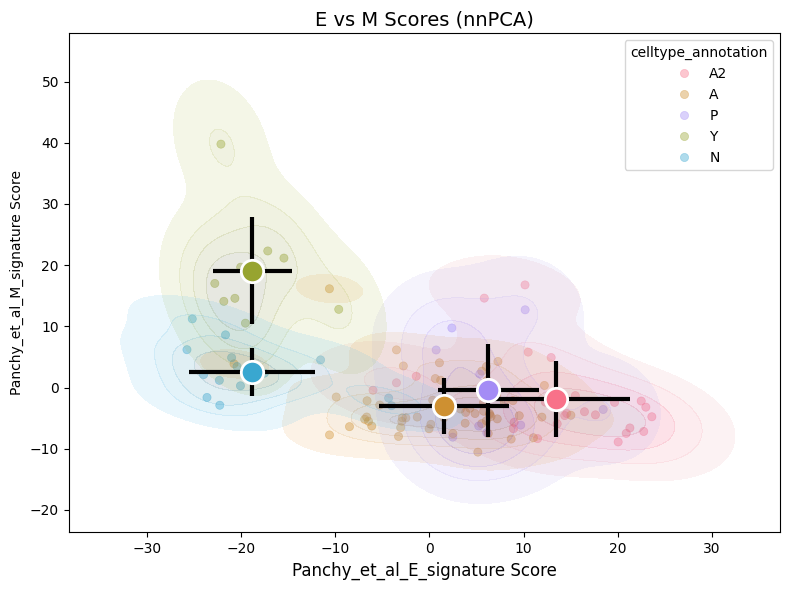

C:\Users\shawn\AppData\Local\Temp\ipykernel_44364\1065907410.py:78: UserWarning: The palette list has more values (13) than needed (5), which may not be intended.
  sns.scatterplot(


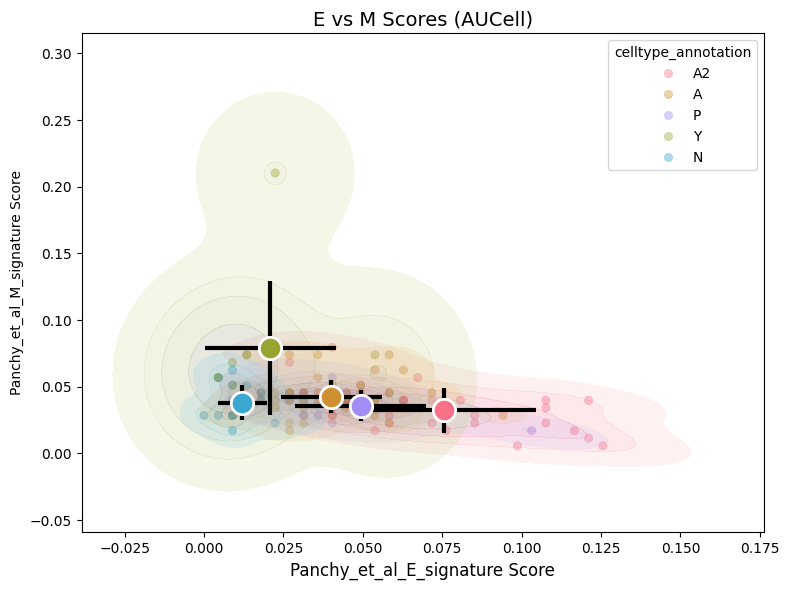

C:\Users\shawn\AppData\Local\Temp\ipykernel_44364\1065907410.py:131: UserWarning: The palette list has more values (13) than needed (5), which may not be intended.
  sns.scatterplot(


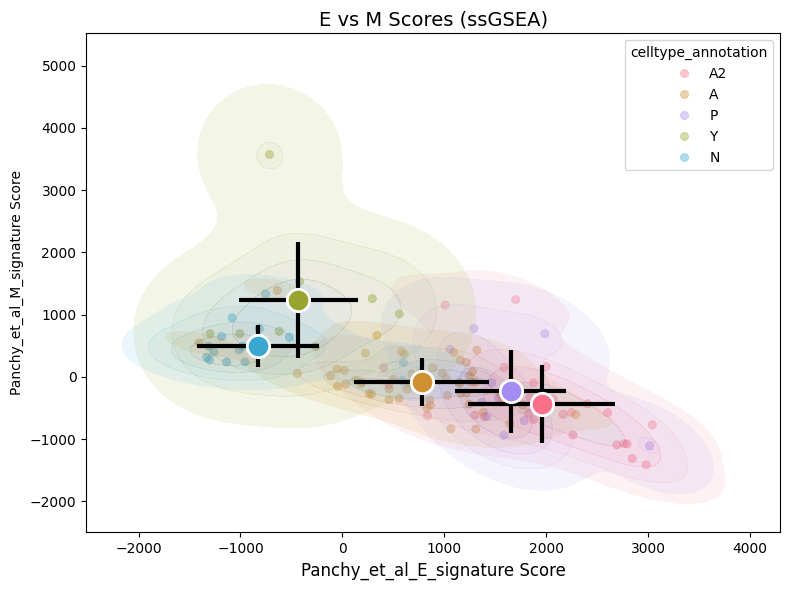

In [22]:
nnPCA_scores_csv = pd.read_csv("data/csv/nnPCA_scores.csv", index_col=0)
aucell_scores_csv = pd.read_csv("data/csv/aucell_scores.csv", index_col=0)
ssgsea_scores_csv = pd.read_csv("data/csv/ssgsea_scores.csv", index_col=0)
cell_annot_csv = pd.read_csv("data/csv/cell_annotation_file.csv")

def prepare_plot_data(scores_df, annotations_df):
    return annotations_df.merge(scores_df, left_on="name", right_index=True)

data_for_plot = prepare_plot_data(nnPCA_scores_csv, cell_annot_csv)
colors = ["#F87189", "#CE9031", "#A48CF5", "#97A430", "#39A7D0", "#E57D5F",
         "#84C7B9", "#E1AF64", "#C26CCF", "#B0BF43", "#57C3E8", "#F29D9E", "#92AAE6"]

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=data_for_plot,
    x="Panchy_et_al_E_signature",
    y="Panchy_et_al_M_signature",
    hue="celltype_annotation",
    palette=colors,
    s=35,
    alpha=0.4,
    edgecolor=None,
)

cell_types = data_for_plot["celltype_annotation"].unique()

for i, ct in enumerate(cell_types):
    subset = data_for_plot[data_for_plot["celltype_annotation"] == ct]
    
    if len(subset) > 5:
        sns.kdeplot(
            data=subset,
            x="Panchy_et_al_E_signature",
            y="Panchy_et_al_M_signature",
            fill=True,
            alpha=0.15,
            levels=5,
            thresh=0.05,
            color=colors[i % len(colors)]
        )
        
for i, ct in enumerate(cell_types):
    subset = data_for_plot[data_for_plot["celltype_annotation"] == ct]
    
    mean_E = subset["Panchy_et_al_E_signature"].mean()
    mean_M = subset["Panchy_et_al_M_signature"].mean()
    sd_E = subset["Panchy_et_al_E_signature"].std()
    sd_M = subset["Panchy_et_al_M_signature"].std() 
    
    plt.errorbar(mean_E, mean_M,
                 xerr=sd_E,
                 yerr=sd_M,
                 fmt='none',
                 ecolor='black',
                 elinewidth=3,
                 capsize=0,
                 zorder=5)
                
    plt.scatter(mean_E, mean_M,
                s=260,
                color=colors[i % len(colors)],
                edgecolor="white",
                linewidth=2,
                zorder=6)
    
    

plt.xlabel("Panchy_et_al_E_signature Score", fontsize=12)
plt.ylabel("Panchy_et_al_M_signature Score")
plt.title("E vs M Scores (nnPCA)", fontsize=14)

plt.tight_layout()
plt.show()

# ---- AUCell Plot ----
aucell_plot = prepare_plot_data(aucell_scores_csv, cell_annot_csv)
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=aucell_plot,
    x="Panchy_et_al_E_signature",
    y="Panchy_et_al_M_signature",
    hue="celltype_annotation",
    palette=colors,
    s=35,
    alpha=0.4,
    edgecolor=None,
)
cell_types = aucell_plot["celltype_annotation"].unique()
for i, ct in enumerate(cell_types):
    subset = aucell_plot[aucell_plot["celltype_annotation"] == ct]
    if len(subset) > 5:
        sns.kdeplot(
            data=subset,
            x="Panchy_et_al_E_signature",
            y="Panchy_et_al_M_signature",
            fill=True,
            alpha=0.15,
            levels=5,
            thresh=0.05,
            color=colors[i % len(colors)]
        )
for i, ct in enumerate(cell_types):
    subset = aucell_plot[aucell_plot["celltype_annotation"] == ct]
    mean_E = subset["Panchy_et_al_E_signature"].mean()
    mean_M = subset["Panchy_et_al_M_signature"].mean()
    sd_E = subset["Panchy_et_al_E_signature"].std()
    sd_M = subset["Panchy_et_al_M_signature"].std() 
    plt.errorbar(mean_E, mean_M,
                 xerr=sd_E,
                 yerr=sd_M,
                 fmt='none',
                 ecolor='black',
                 elinewidth=3,
                 capsize=0,
                 zorder=5)
    plt.scatter(mean_E, mean_M,
                s=260,
                color=colors[i % len(colors)],
                edgecolor="white",
                linewidth=2,
                zorder=6)
plt.xlabel("Panchy_et_al_E_signature Score", fontsize=12)
plt.ylabel("Panchy_et_al_M_signature Score")
plt.title("E vs M Scores (AUCell)", fontsize=14)
plt.tight_layout()
plt.show()

# ---- ssGSEA Plot ----
ssgsea_plot = prepare_plot_data(ssgsea_scores_csv, cell_annot_csv)
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=ssgsea_plot,
    x="Panchy_et_al_E_signature",
    y="Panchy_et_al_M_signature",
    hue="celltype_annotation",
    palette=colors,
    s=35,
    alpha=0.4,
    edgecolor=None,
)
cell_types = ssgsea_plot["celltype_annotation"].unique()
for i, ct in enumerate(cell_types):
    subset = ssgsea_plot[ssgsea_plot["celltype_annotation"] == ct]
    if len(subset) > 5:
        sns.kdeplot(
            data=subset,
            x="Panchy_et_al_E_signature",
            y="Panchy_et_al_M_signature",
            fill=True,
            alpha=0.15,
            levels=5,
            thresh=0.05,
            color=colors[i % len(colors)]
        )
for i, ct in enumerate(cell_types):
    subset = ssgsea_plot[ssgsea_plot["celltype_annotation"] == ct]
    mean_E = subset["Panchy_et_al_E_signature"].mean()
    mean_M = subset["Panchy_et_al_M_signature"].mean()
    sd_E = subset["Panchy_et_al_E_signature"].std()
    sd_M = subset["Panchy_et_al_M_signature"].std() 
    plt.errorbar(mean_E, mean_M,
                 xerr=sd_E,
                 yerr=sd_M,
                 fmt='none',
                 ecolor='black',
                 elinewidth=3,
                 capsize=0,
                 zorder=5)
    plt.scatter(mean_E, mean_M,
                s=260,
                color=colors[i % len(colors)],
                edgecolor="white",
                linewidth=2,
                zorder=6)
plt.xlabel("Panchy_et_al_E_signature Score", fontsize=12)
plt.ylabel("Panchy_et_al_M_signature Score")
plt.title("E vs M Scores (ssGSEA)", fontsize=14)
plt.tight_layout()
plt.show()

